In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import math
import seaborn as sns
from datetime import timedelta
import matplotlib.ticker as tkr
from sklearn.cluster import KMeans

def custom_grouping(index):
    return index // 1000

names_latency=['submission_time', 'duration', 'op2', 'write_size', 'op3']
columns = ['submission_time', 'duration', 'write_size']



In [3]:
df2= pd.read_csv('/home/surbhi/measurements/STL/cache/uniform-random/run2/lat_log_avg_lat.1.log', sep=',' , names=names_latency, usecols=columns)
# Convert nanoseconds to microseconds for the 'time' column
df2['duration'] = df2['duration'] / 1000000  # Convert nanoseconds to milliseconds
# Calculate cumulative GBs of data written
df2['cumulative_gb'] = np.floor(df2['write_size'].cumsum() / (1024**3))
df2['submission_time'] = df2['submission_time'] - df2.iloc[0].submission_time #+ df_grouped1.index.max() + 60 * 60
df2['completion_time'] = np.floor(df2['submission_time'] + df2['duration'])

In [16]:
# Step 3: Determine the start and end time of the entire test
start_time = int(df2['submission_time'].min())
end_time = int(df2['completion_time'].max())


# Step 4: Create new DataFrames to represent each  millisecond between the start and end time of the entire test
data_written_ms2 = pd.DataFrame(index=range(start_time, end_time + 1, 1), columns=['data_written_bytes'])
data_written_ms2['data_written_bytes'] = 0

# Step 5: Iterate through each write request, calculate the data size for each time interval, and update the corresponding entries in the DataFrames
for index, row in df2.iterrows():
    duration = row['duration']
    start = int(row['submission_time'])
    end = start+math.floor(duration)
    
    payload = 1048576
    write_rate_per_ms = payload / max(duration, 1.)
    assert(write_rate_per_ms <= payload)
    residue = payload - write_rate_per_ms * math.floor(duration)
    assert (payload >= (write_rate_per_ms * math.floor(duration)))
    data_written_ms2.loc[start:end-1] += write_rate_per_ms
    # residue could be zero when last == end
    data_written_ms2.loc[end] += residue

print(index)
data_written_ms2.reset_index(drop=True, inplace=True)
last_non_zero_index = data_written_ms2[data_written_ms2.ne(0).any(axis=1)].index[-1]
data_written_ms2 = data_written_ms2.loc[:last_non_zero_index]

/tmp/ipykernel_320321/3143466188.py:21: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[210.8010519 210.8010519 210.8010519 ... 210.8010519 210.8010519
 210.8010519]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  data_written_ms2.loc[start:end-1] += write_rate_per_ms


35839


In [17]:
chunk_size = 100000
results = []

for i in range(0, len(data_written_ms2), chunk_size):
    chunk = data_written_ms2.iloc[i:i+chunk_size]
    result = chunk.groupby(custom_grouping).sum()
    results.append(result)

df_grouped2 = pd.concat(results)

# Reset the index to make it a regular column
df_grouped2.reset_index(inplace=True)
df_grouped2['cumulative_gb'] = df_grouped2['data_written_bytes'].cumsum() / (1024 ** 3)
df_grouped2['data_written_bytes'] = df_grouped2['data_written_bytes'] / (1024 ** 2) 
df_grouped2.reset_index(drop=True, inplace=True)
last_non_zero_index = df_grouped2[df_grouped2.ne(0).any(axis=1)].index[-1]
df_grouped2 = df_grouped2.loc[:last_non_zero_index]
df_grouped2['latency'] =1 / df_grouped2['data_written_bytes']
#
#data_array = df_grouped['data_written_bytes'].values.reshape(-1, 1)
print(df_grouped2.describe())
print(df_grouped2.info())

             index  data_written_bytes  cumulative_gb      latency
count  5008.000000         5008.000000    5008.000000  5008.000000
mean   2503.500000            7.156550      17.441471          inf
std    1445.829404            3.009192      10.207250          NaN
min       0.000000            0.000000       0.005568     0.024067
25%    1251.750000            6.003239       8.588643     0.127164
50%    2503.500000            6.353993      17.453281     0.157381
75%    3755.250000            7.863865      26.308031     0.166577
max    5007.000000           41.551204      35.000000          inf
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5008 entries, 0 to 5007
Data columns (total 4 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   index               5008 non-null   int64  
 1   data_written_bytes  5008 non-null   float64
 2   cumulative_gb       5008 non-null   float64
 3   latency             5008 non-null   float

/home/surbhi/.local/lib/python3.10/site-packages/pandas/core/nanops.py:1010: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


/tmp/ipykernel_320321/4203118407.py:7: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc='center right', fontsize=14)


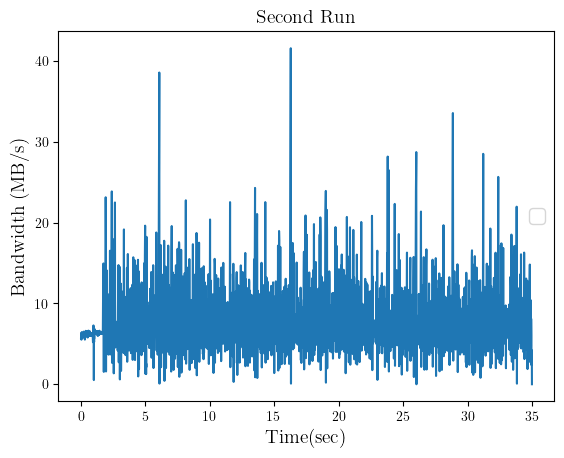

In [20]:
import matplotlib.ticker as ticker
# Custom function to format y-axis ticks
plt.rc('text', usetex=True)
plt.rc('font', family='serif')
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42
plt.legend(loc='center right', fontsize=14)
#plt.plot(df_grouped.index, df_grouped['data_written_bytes'])

#plt.xscale('log', base=10)
#plt.yscale('log', base=2)


#plt.xlabel('Logarithmic (base 10) Time in seconds', fontsize=14)
#plt.ylabel('Logarithmic (base 2) Bandwidth (MB/sec)', fontsize=14)

plt.xlabel('Time(sec)', fontsize=14)
plt.ylabel('Bandwidth (MB/s)', fontsize=14)

plt.plot(df_grouped2['cumulative_gb'], df_grouped2['data_written_bytes'])
plt.title('Second Run ', fontsize=14, fontweight='bold')   
#plt.xlabel(r'$\textbf{Normal}$ text and $\textbf{Bold text}$')   
#plt.savefig('/home/surbhi/github/surbhi-plots/new/STL/4K_90Util_STL_BW.pdf', bbox_inches='tight', format="pdf")
plt.show()
